In [1]:
from tweepy import API 
from tweepy import Cursor
from tweepy.streaming import StreamListener
from tweepy import OAuthHandler
from tweepy import Stream

from textblob import TextBlob
 
#import twitter_credentials

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re

ACCESS_TOKEN ="1511746246494593032-u3t18TrXTsBT5SNqwh7yRNx1RW7AmA"
ACCESS_TOKEN_SECRET ="3JJzKQFI7O5lu2qs4ks4sQQn1ximGeKMYUPJg5sFgtpyb"
CONSUMER_KEY ="k8WtNYDfJt7D5WYX4KKQ2CqFM"
CONSUMER_SECRET ="wmz9QIFnpXQa7jsFmHypOb8koAygZvdWNbWDVKWBcx5WAnSAW2"

# # # # TWITTER CLIENT # # # #
class TwitterClient():
    def __init__(self, twitter_user=None):
        self.auth = TwitterAuthenticator().authenticate_twitter_app()
        self.twitter_client = API(self.auth)

        self.twitter_user = twitter_user

    def get_twitter_client_api(self):
        return self.twitter_client

    def get_user_timeline_tweets(self, num_tweets):
        tweets = []
        for tweet in Cursor(self.twitter_client.user_timeline, id=self.twitter_user).items(num_tweets):
            tweets.append(tweet)
        return tweets

    def get_friend_list(self, num_friends):
        friend_list = []
        for friend in Cursor(self.twitter_client.friends, id=self.twitter_user).items(num_friends):
            friend_list.append(friend)
        return friend_list

    def get_home_timeline_tweets(self, num_tweets):
        home_timeline_tweets = []
        for tweet in Cursor(self.twitter_client.home_timeline, id=self.twitter_user).items(num_tweets):
            home_timeline_tweets.append(tweet)
        return home_timeline_tweets


# # # # TWITTER AUTHENTICATER # # # #
class TwitterAuthenticator():

    def authenticate_twitter_app(self):
        auth = OAuthHandler(CONSUMER_KEY, CONSUMER_SECRET)
        auth.set_access_token(ACCESS_TOKEN,ACCESS_TOKEN_SECRET)
        return auth

# # # # TWITTER STREAMER # # # #
class TwitterStreamer():
    """
    Class for streaming and processing live tweets.
    """
    def __init__(self):
        self.twitter_autenticator = TwitterAuthenticator()    

    def stream_tweets(self, fetched_tweets_filename, hash_tag_list):
        # This handles Twitter authetification and the connection to Twitter Streaming API
        listener = TwitterListener(fetched_tweets_filename)
        auth = self.twitter_autenticator.authenticate_twitter_app() 
        stream = Stream(auth, listener)

        # This line filter Twitter Streams to capture data by the keywords: 
        stream.filter(track=hash_tag_list)


# # # # TWITTER STREAM LISTENER # # # #
class TwitterListener(StreamListener):
    """
    This is a basic listener that just prints received tweets to stdout.
    """
    def __init__(self, fetched_tweets_filename):
        self.fetched_tweets_filename = fetched_tweets_filename

    def on_data(self, data):
        try:
            print(data)
            with open(self.fetched_tweets_filename, 'a') as tf:
                tf.write(data)
            return True
        except BaseException as e:
            print("Error on_data %s" % str(e))
        return True
          
    def on_error(self, status):
        if status == 420:
            # Returning False on_data method in case rate limit occurs.
            return False
        print(status)


class TweetAnalyzer():
    """
    Functionality for analyzing and categorizing content from tweets.
    """

    def clean_tweet(self, tweet):
        return ' '.join(re.sub("(@[A-Za-z0-9]+)|([^0-9A-Za-z \t])|(\w+:\/\/\S+)", " ", tweet).split())

    def analyze_sentiment(self, tweet):
        analysis = TextBlob(self.clean_tweet(tweet))
        
        if analysis.sentiment.polarity > 0:
            return 1
        elif analysis.sentiment.polarity == 0:
            return 0
        else:
            return -1

    def tweets_to_data_frame(self, tweets):
        df = pd.DataFrame(data=[tweet.text for tweet in tweets], columns=['tweets'])

        df['id'] = np.array([tweet.id for tweet in tweets])
        df['len'] = np.array([len(tweet.text) for tweet in tweets])
        df['date'] = np.array([tweet.created_at for tweet in tweets])
        df['source'] = np.array([tweet.source for tweet in tweets])
        df['likes'] = np.array([tweet.favorite_count for tweet in tweets])
        df['retweets'] = np.array([tweet.retweet_count for tweet in tweets])

        return df

 
if __name__ == '__main__':

    twitter_client = TwitterClient()
    tweet_analyzer = TweetAnalyzer()

    api = twitter_client.get_twitter_client_api()

    tweets = api.user_timeline(screen_name="@SonkoOfficiel", count=200)

    df = tweet_analyzer.tweets_to_data_frame(tweets)
    df['sentiment'] = np.array([tweet_analyzer.analyze_sentiment(tweet) for tweet in df['tweets']])
    # enregistrer les donnees
    df.to_pickle('Sonko.gzip') 
    # lire le fichier
    pd.read_pickle('Sonko.gzip')
    print(df.head(10))

                                              tweets                   id  \
0  Chers compatriotes,\n\nJe vous donne rendez-vo...  1528866660433920000   
1             #NewProfilePic https://t.co/qFFZVUFkEy  1526923824968650754   
2  Nous vous donnons rendez-vous demain au Tribun...  1526715802719817728   
3  J'apporte tout mon soutien à Idrissa Gana Guey...  1526715800165437443   
4  de la décision de la Cour de Cassation. Il rev...  1526715797573447680   
5  Elle doit accepter la rectification que Déthié...  1526715795153330177   
6  Cependant, cela ne signifie aucunement que la ...  1526715792628252673   
7  2-Une fois à la DGE, la fatigue et la faim ont...  1526715790166315010   
8  1- Khalifa Sall a tardé de prendre une décisio...  1526715787721023489   
9  Il n'y a eu ni complot ni plan de Macky Sall. ...  1526715785363738631   

   len                date              source  likes  retweets  sentiment  
0  100 2022-05-23 22:33:11  Twitter for iPhone   1928       223          0 

In [2]:
# lire le fichier
pd.read_pickle('Sonko.gzip')

,tweets,id,len,date,source,likes,retweets,sentiment
0,"Chers compatriotes,\n\nJe vous donne rendez-vo...",1528866660433920000,100,2022-05-23 22:33:11,Twitter for iPhone,1928,223,0
1,#NewProfilePic https://t.co/qFFZVUFkEy,1526923824968650754,38,2022-05-18 13:53:03,Twitter for iPhone,3458,242,0
2,Nous vous donnons rendez-vous demain au Tribun...,1526715802719817728,140,2022-05-18 00:06:27,Twitter Web App,1173,116,0
3,J'apporte tout mon soutien à Idrissa Gana Guey...,1526715800165437443,140,2022-05-18 00:06:26,Twitter Web App,3690,860,0
4,de la décision de la Cour de Cassation. Il rev...,1526715797573447680,140,2022-05-18 00:06:25,Twitter Web App,584,69,0
...,...,...,...,...,...,...,...,...
195,Que chaque jeune vérifie dès à présent son sta...,1423674201001574407,140,2021-08-06 15:55:54,Twitter Web App,149,41,0
196,Que les personnes détentrices de cartes d’iden...,1423674198782775300,140,2021-08-06 15:55:54,Twitter Web App,145,36,0
197,Que les personnes qui n'avaient pas retiré leu...,1423674196580786177,140,2021-08-06 15:55:53,Twitter Web App,135,32,0
198,"Que les moins de 18 ans, et qui atteindront l'...",1423674194131361794,140,2021-08-06 15:55:53,Twitter Web App,147,31,0


In [6]:
!pip install textblob-fr

     |████████████████████████████████| 561 kB 255 kB/s eta 0:00:01


In [6]:
print((df['sentiment']==-1).value_counts())


False    197
True       3
Name: sentiment, dtype: int64


In [10]:
print(df.shape)

(200, 8)


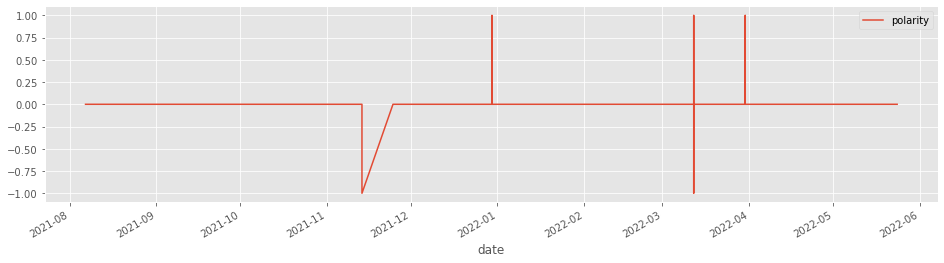

In [3]:
plt.style.use('ggplot')
time_likes = pd.Series(data=df['sentiment'].values, index=df['date'])
time_likes.plot(figsize=(16, 4), label="polarity", legend=True)
plt.savefig("polarity_Sonko.png", dpi=500)


In [22]:
print(df[:])


                                                tweets                   id  \
0    Je prends part ce samedi 4 juin, à  Accra, au ...  1533086046312882177   
1    Je félicite le khalife des Niassénes Cheikh Mo...  1532871216607944704   
2    President #Putin expressed to us his readiness...  1532815016998719488   
3    I would like to thank President #Putin for his...  1532782632764854272   
4    Le Président #Poutine nous a exprimé sa dispon...  1532740261658431489   
..                                                 ...                  ...   
195  RT @PR_Senegal: Le Président de la République ...  1495797357362954249   
196  Au terme de ce sommet Union européenne-Union a...  1494717209524023299   
197  📌 #EUAUSummit \n🗣️ Conférence de presse avec @...  1494666500740943875   
198  Cette Afrique en pleine mutation veut des part...  1494434767005171719   
199  A l’ère des complémentarités et des interdépen...  1494372288380166147   

     len                date              source  l